# Part 4: Mitigation - Making the Classifier Fairer and More Robust

This notebook implements three mitigation techniques and compares them to the baseline:
1. Reweighing (pre-processing, with AIF360)
2. Threshold optimization (post-processing, with Fairlearn equalized odds)
3. Oversampling high-black cohort (data-level augmentation)

Outputs include:
- Fairness/utility comparison table for baseline + 3 techniques
- Pareto frontier (fairness vs F1) for threshold-tolerance sweep
- Base-rate analysis for demographic parity vs equalized odds compatibility
- Saved checkpoint for the best-performing mitigated retrained model

In [2]:
# Uncomment if needed in your environment.
# !pip install -q transformers datasets accelerate scikit-learn seaborn pandas matplotlib aif360 fairlearn torch

import os
import shutil
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from datasets import Dataset
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding, Trainer, TrainingArguments, set_seed

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric

from fairlearn.postprocessing import ThresholdOptimizer

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["WANDB_DISABLED"] = "true"

SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
DATA_PATH = os.path.join("dataset", "jigsaw-unintended-bias-train.csv")
USECOLS = ["comment_text", "toxic", "black", "white"]

MODEL_BASE = "distilbert-base-uncased"
PART1_CHECKPOINT_DIR = os.path.join("checkpoints", "part1_distilbert_baseline")
BEST_MITIGATED_DIR = os.path.join("checkpoints", "part4_best_mitigated")

BASE_THRESHOLD = 0.3  # Using chosen operating threshold from Part 1

TRAIN_SIZE = 100_000
EVAL_SIZE = 20_000
EPOCHS = 3

if not os.path.isdir(PART1_CHECKPOINT_DIR):
    raise FileNotFoundError(
        f"Missing Part 1 checkpoint at {PART1_CHECKPOINT_DIR}. Run part1.ipynb first."
    )

In [4]:
df = pd.read_csv(
    DATA_PATH,
    usecols=USECOLS,
    dtype={
        "comment_text": "string",
        "toxic": "float32",
        "black": "float32",
        "white": "float32",
    },
)

df = df.dropna(subset=["comment_text", "toxic", "black", "white"]).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

train_df, eval_df = train_test_split(
    df,
    train_size=TRAIN_SIZE,
    test_size=EVAL_SIZE,
    stratify=df["label"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
eval_df = eval_df.reset_index(drop=True)

def cohort_masks(frame):
    high_black = frame["black"] >= 0.5
    reference = (frame["black"] < 0.1) & (frame["white"] >= 0.5)
    return high_black, reference

train_hb_mask, train_ref_mask = cohort_masks(train_df)
eval_hb_mask, eval_ref_mask = cohort_masks(eval_df)

print(f"Train rows: {len(train_df):,}")
print(f"Eval rows:  {len(eval_df):,}")
print(f"Train high-black: {train_hb_mask.sum():,}")
print(f"Train reference:  {train_ref_mask.sum():,}")
print(f"Eval high-black:  {eval_hb_mask.sum():,}")
print(f"Eval reference:   {eval_ref_mask.sum():,}")

Train rows: 100,000
Eval rows:  20,000
Train high-black: 3,761
Train reference:  4,354
Eval high-black:  710
Eval reference:   856


In [5]:
def tokenize_df(df_in, tokenizer):
    cols = ["comment_text", "label"]
    if "sample_weight" in df_in.columns:
        cols.append("sample_weight")
    ds = Dataset.from_pandas(df_in[cols], preserve_index=False)

    def tok(batch):
        return tokenizer(batch["comment_text"], truncation=True, max_length=128)

    ds = ds.map(tok, batched=True, remove_columns=["comment_text"])
    ds = ds.rename_column("label", "labels")
    return ds

def predict_probs(model, tokenizer, texts):
    ds = Dataset.from_dict({"comment_text": list(texts)})

    def tok(batch):
        return tokenizer(batch["comment_text"], truncation=True, max_length=128)

    ds = ds.map(tok, batched=True, remove_columns=["comment_text"])

    args = TrainingArguments(
        output_dir="checkpoints/part4_inference_tmp",
        per_device_eval_batch_size=64 if torch.cuda.is_available() else 8,
        report_to="none",
    )
    tr = Trainer(
        model=model,
        args=args,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    )
    pred = tr.predict(ds).predictions
    probs = torch.softmax(torch.tensor(pred), dim=-1).numpy()[:, 1]
    return probs

def rates_from_preds(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
    return tpr, fpr

def fairness_metrics(eval_frame, pred_labels):
    y_true = eval_frame["label"].to_numpy()
    y_pred = np.asarray(pred_labels).astype(int)

    hb_mask, ref_mask = cohort_masks(eval_frame)

    y_true_hb = y_true[hb_mask]
    y_pred_hb = y_pred[hb_mask]
    y_true_ref = y_true[ref_mask]
    y_pred_ref = y_pred[ref_mask]

    tpr_hb, fpr_hb = rates_from_preds(y_true_hb, y_pred_hb)
    tpr_ref, fpr_ref = rates_from_preds(y_true_ref, y_pred_ref)

    audit_mask = hb_mask | ref_mask
    audit = eval_frame.loc[audit_mask, ["label", "black"]].copy()
    audit["pred"] = y_pred[audit_mask]
    audit["group"] = np.where(audit["black"] >= 0.5, 1, 0)

    true_bld = BinaryLabelDataset(
        df=audit[["label", "group"]].copy(),
        label_names=["label"],
        protected_attribute_names=["group"],
        favorable_label=1,
        unfavorable_label=0,
    )
    pred_bld = BinaryLabelDataset(
        df=audit[["pred", "group"]].rename(columns={"pred": "label"}),
        label_names=["label"],
        protected_attribute_names=["group"],
        favorable_label=1,
        unfavorable_label=0,
    )

    cm = ClassificationMetric(
        true_bld,
        pred_bld,
        unprivileged_groups=[{"group": 1}],
        privileged_groups=[{"group": 0}],
    )

    return {
        "Overall_F1": f1_score(y_true, y_pred, average="macro"),
        "HighBlack_FPR": fpr_hb,
        "Reference_FPR": fpr_ref,
        "SPD": cm.statistical_parity_difference(),
        "EOD": cm.equal_opportunity_difference(),
        "HB_TPR": tpr_hb,
        "REF_TPR": tpr_ref,
        "HB_FPR": fpr_hb,
        "REF_FPR": fpr_ref,
    }

In [6]:
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        sample_weight = inputs.pop("sample_weight", None)
        labels = inputs.get("labels")

        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = torch.nn.CrossEntropyLoss(reduction="none")
        loss = loss_fct(logits.view(-1, model.config.num_labels), labels.view(-1))

        if sample_weight is not None:
            sample_weight = sample_weight.to(loss.device).float().view(-1)
            loss = (loss * sample_weight).sum() / sample_weight.sum().clamp_min(1e-8)
        else:
            loss = loss.mean()

        return (loss, outputs) if return_outputs else loss

def train_distilbert(train_frame, eval_frame, output_dir, use_weights=False):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_BASE)
    model = AutoModelForSequenceClassification.from_pretrained(MODEL_BASE, num_labels=2)

    train_ds = tokenize_df(train_frame, tokenizer)
    eval_ds = tokenize_df(eval_frame[["comment_text", "label"]], tokenizer)

    args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=EPOCHS,
        learning_rate=2e-5,
        weight_decay=0.01,
        per_device_train_batch_size=16 if torch.cuda.is_available() else 4,
        per_device_eval_batch_size=32 if torch.cuda.is_available() else 8,
        gradient_accumulation_steps=1 if torch.cuda.is_available() else 4,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=100,
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        report_to="none",
        fp16=torch.cuda.is_available(),
        seed=SEED,
        remove_unused_columns=False if use_weights else True,
    )

    trainer_cls = WeightedTrainer if use_weights else Trainer
    trainer = trainer_cls(
        model=model,
        args=args,
        train_dataset=train_ds,
        eval_dataset=eval_ds,
        data_collator=DataCollatorWithPadding(tokenizer=tokenizer),
    )

    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

    probs_eval = predict_probs(model, tokenizer, eval_frame["comment_text"].tolist())
    preds_eval = (probs_eval >= BASE_THRESHOLD).astype(int)
    metrics = fairness_metrics(eval_frame, preds_eval)

    return {
        "model": model,
        "tokenizer": tokenizer,
        "probs_eval": probs_eval,
        "preds_eval": preds_eval,
        "metrics": metrics,
        "output_dir": output_dir,
    }

## Baseline Evaluation (Part 1 Checkpoint)

In [7]:
baseline_tokenizer = AutoTokenizer.from_pretrained(PART1_CHECKPOINT_DIR)
baseline_model = AutoModelForSequenceClassification.from_pretrained(PART1_CHECKPOINT_DIR, num_labels=2)

baseline_probs = predict_probs(baseline_model, baseline_tokenizer, eval_df["comment_text"].tolist())
baseline_preds = (baseline_probs >= BASE_THRESHOLD).astype(int)
baseline_metrics = fairness_metrics(eval_df, baseline_preds)

print("Baseline metrics computed from Part 1 checkpoint.")
print(pd.DataFrame([baseline_metrics]).round(4).to_string(index=False))

Map: 100%|██████████| 20000/20000 [00:02<00:00, 8134.12 examples/s]


Baseline metrics computed from Part 1 checkpoint.
 Overall_F1  HighBlack_FPR  Reference_FPR    SPD    EOD  HB_TPR  REF_TPR  HB_FPR  REF_FPR
      0.797         0.2182         0.1079 0.1204 0.0782  0.6977   0.6195  0.2182   0.1079


## Technique 1: Reweighing (Pre-processing)

In [8]:
train_rew = train_df[["comment_text", "label", "black", "white"]].copy()
train_rew["sample_weight"] = 1.0

rw_subset_mask = train_hb_mask | train_ref_mask
rw_subset = train_rew.loc[rw_subset_mask, ["label", "black", "white"]].copy()
rw_subset["group"] = np.where(rw_subset["black"] >= 0.5, 1, 0)

rw_bld = BinaryLabelDataset(
    df=rw_subset[["label", "group"]],
    label_names=["label"],
    protected_attribute_names=["group"],
    favorable_label=1,
    unfavorable_label=0,
)

rw = Reweighing(unprivileged_groups=[{"group": 1}], privileged_groups=[{"group": 0}])
rw_bld_transf = rw.fit_transform(rw_bld)
rw_weights = rw_bld_transf.instance_weights.ravel()

train_rew.loc[rw_subset_mask, "sample_weight"] = rw_weights
train_rew["sample_weight"] = train_rew["sample_weight"] / train_rew["sample_weight"].mean()

print("Reweighing weights summary:")
print(train_rew["sample_weight"].describe().to_string())

reweigh_out = train_distilbert(
    train_rew[["comment_text", "label", "sample_weight"]],
    eval_df[["comment_text", "label", "black", "white"]],
    output_dir=os.path.join("checkpoints", "part4_reweighing"),
    use_weights=True,
)

print("Reweighing metrics:")
print(pd.DataFrame([reweigh_out["metrics"]]).round(4).to_string(index=False))

Reweighing weights summary:
count    100000.000000
mean          1.000000
std           0.012047
min           0.933642
25%           1.000000
50%           1.000000
75%           1.000000
max           1.065410


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 10956.91it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 20000/20000 [00:02<00:00, 8233.05 examples/s]


Epoch,Training Loss,Validation Loss
1,0.200316,0.202811
2,0.185010,0.208326
3,0.089342,0.285935


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.05it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Map: 100%|██████████| 20000/20000 [00:02<00:00, 8296.23 examples/s]


Reweighing metrics:
 Overall_F1  HighBlack_FPR  Reference_FPR    SPD     EOD  HB_TPR  REF_TPR  HB_FPR  REF_FPR
     0.7804         0.4626         0.4222 0.0427 -0.0108  0.8698   0.8805  0.4626   0.4222


## Technique 2: Threshold Optimization (Post-processing, Equalized Odds)

In [ ]:
class HFTextEstimator(BaseEstimator, ClassifierMixin):
    def __init__(self, model, tokenizer):
        self.model = model
        self.tokenizer = tokenizer

    def fit(self, X, y):
        return self

    def predict_proba(self, X):
        if isinstance(X, pd.DataFrame):
            texts = X.iloc[:, 0].astype(str).to_numpy()
        elif isinstance(X, pd.Series):
            texts = X.astype(str).to_numpy()
        else:
            texts = np.asarray(X).reshape(-1).astype(str)
        probs = predict_probs(self.model, self.tokenizer, texts.tolist())
        return np.column_stack([1 - probs, probs]).astype(np.float64)

    def predict(self, X):
        p = self.predict_proba(X)[:, 1]
        return (p >= BASE_THRESHOLD).astype(int)

group_eval = np.where(eval_hb_mask.to_numpy(), "high_black", np.where(eval_ref_mask.to_numpy(), "reference", "other"))
sensitive_eval = np.asarray(group_eval, dtype=object)

th_opt = ThresholdOptimizer(
    estimator=HFTextEstimator(baseline_model, baseline_tokenizer),
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    prefit=True,
)

th_fit_X = eval_df[["comment_text"]].to_numpy()
th_fit_y = eval_df["label"].to_numpy().astype(int)

th_opt.fit(
    th_fit_X,
    th_fit_y,
    sensitive_features=sensitive_eval,
)

thopt_preds = th_opt.predict(
    th_fit_X,
    sensitive_features=sensitive_eval,
).astype(int)

thopt_metrics = fairness_metrics(eval_df, thopt_preds)
print("ThresholdOptimizer metrics (strict equalized odds):")
print(pd.DataFrame([thopt_metrics]).round(4).to_string(index=False))

Map: 100%|██████████| 20000/20000 [00:02<00:00, 8138.97 examples/s]


Map: 100%|██████████| 20000/20000 [00:02<00:00, 8138.97 examples/s]


Map: 100%|██████████| 20000/20000 [00:02<00:00, 8138.97 examples/s]


Map: 100%|██████████| 20000/20000 [00:02<00:00, 7876.94 examples/s]


Map: 100%|██████████| 20000/20000 [00:02<00:00, 8138.97 examples/s]


Map: 100%|██████████| 20000/20000 [00:02<00:00, 7876.94 examples/s]


Map: 100%|██████████| 20000/20000 [00:02<00:00, 8138.97 examples/s]


Map: 100%|██████████| 20000/20000 [00:02<00:00, 7876.94 examples/s]


ThresholdOptimizer metrics (strict equalized odds):
 Overall_F1  HighBlack_FPR  Reference_FPR   SPD     EOD  HB_TPR  REF_TPR  HB_FPR  REF_FPR
     0.6592         0.1879            0.2 0.006 -0.0156  0.6791   0.6947  0.1879      0.2


Pareto sweep results:
 Tolerance  Threshold_HB  Threshold_REF  Overall_F1  EqualOpportunityDiff  AbsEOD
     0.025          0.75           0.55      0.7947               -0.0052  0.0052
     0.050          0.40           0.20      0.7980               -0.0210  0.0210
     0.075          0.35           0.20      0.7981               -0.0023  0.0023
     0.100          0.35           0.20      0.7981               -0.0023  0.0023
     0.125          0.35           0.20      0.7981               -0.0023  0.0023
     0.150          0.35           0.20      0.7981               -0.0023  0.0023
     0.175          0.35           0.20      0.7981               -0.0023  0.0023
     0.200          0.35           0.20      0.7981               -0.0023  0.0023
     0.225          0.35           0.20      0.7981               -0.0023  0.0023
     0.250          0.35           0.20      0.7981               -0.0023  0.0023
     0.275          0.35           0.20      0.7981               -0.0023  0

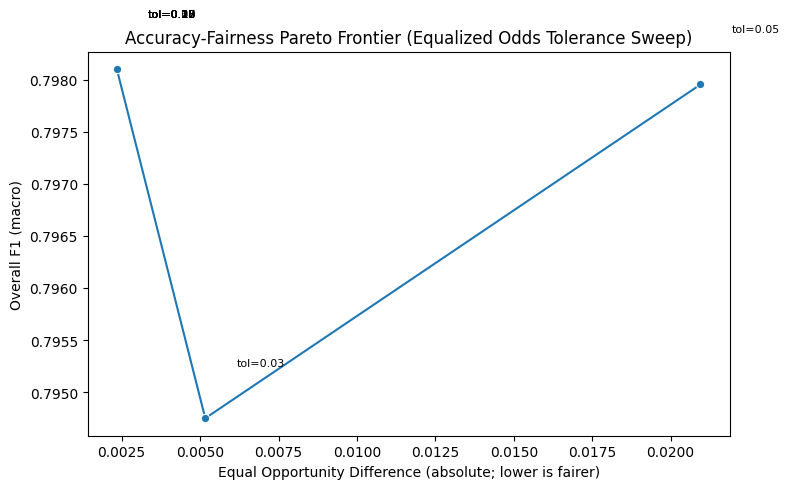

In [12]:
# Pareto frontier by sweeping equalized-odds tolerance with a constrained threshold search.
# (ThresholdOptimizer itself has no explicit tolerance knob in many versions.)

eval_probs_base = baseline_probs.copy()
y_eval = eval_df["label"].to_numpy()

hb_idx = np.where(eval_hb_mask.to_numpy())[0]
ref_idx = np.where(eval_ref_mask.to_numpy())[0]
other_idx = np.where((~eval_hb_mask & ~eval_ref_mask).to_numpy())[0]

def apply_group_thresholds(probs, th_hb, th_ref, th_other=BASE_THRESHOLD):
    pred = np.zeros_like(probs, dtype=int)
    pred[hb_idx] = (probs[hb_idx] >= th_hb).astype(int)
    pred[ref_idx] = (probs[ref_idx] >= th_ref).astype(int)
    pred[other_idx] = (probs[other_idx] >= th_other).astype(int)
    return pred

tolerances = np.round(np.linspace(0.0, 0.3, 13), 3)
grid = np.round(np.linspace(0.05, 0.95, 19), 2)
pareto_rows = []

for tol in tolerances:
    best = None
    for th_hb in grid:
        for th_ref in grid:
            pred = apply_group_thresholds(eval_probs_base, th_hb, th_ref, BASE_THRESHOLD)

            tpr_hb, fpr_hb = rates_from_preds(y_eval[hb_idx], pred[hb_idx])
            tpr_ref, fpr_ref = rates_from_preds(y_eval[ref_idx], pred[ref_idx])

            if np.isnan(tpr_hb) or np.isnan(tpr_ref) or np.isnan(fpr_hb) or np.isnan(fpr_ref):
                continue

            if abs(tpr_hb - tpr_ref) <= tol and abs(fpr_hb - fpr_ref) <= tol:
                f1 = f1_score(y_eval, pred, average="macro")
                eod = tpr_hb - tpr_ref
                if (best is None) or (f1 > best["Overall_F1"]):
                    best = {
                        "Tolerance": tol,
                        "Threshold_HB": th_hb,
                        "Threshold_REF": th_ref,
                        "Overall_F1": f1,
                        "EqualOpportunityDiff": eod,
                        "AbsEOD": abs(eod),
                    }

    if best is not None:
        pareto_rows.append(best)

pareto_df = pd.DataFrame(pareto_rows)
print("Pareto sweep results:")
print(pareto_df.round(4).to_string(index=False))

plt.figure(figsize=(8, 5))
sns.lineplot(data=pareto_df, x="AbsEOD", y="Overall_F1", marker="o")
for _, r in pareto_df.iterrows():
    plt.text(r["AbsEOD"] + 0.001, r["Overall_F1"] + 0.0005, f"tol={r['Tolerance']:.2f}", fontsize=8)
plt.xlabel("Equal Opportunity Difference (absolute; lower is fairer)")
plt.ylabel("Overall F1 (macro)")
plt.title("Accuracy-Fairness Pareto Frontier (Equalized Odds Tolerance Sweep)")
plt.tight_layout()
plt.show()

## Technique 3: Oversampling (Data Augmentation)

In [18]:
# Oversampling: duplicate high-black training samples 3x (total 4 instances per original row)
train_oversample = train_df[["comment_text", "label", "black", "white"]].copy()

# Identify high-black rows in training set
oversample_mask = train_hb_mask

# Duplicate high-black rows 3 times and append
hb_rows = train_oversample.loc[oversample_mask].copy()
train_oversample_augmented = pd.concat([train_oversample, hb_rows, hb_rows, hb_rows], ignore_index=True)

print(f"Original training size: {len(train_oversample):,}")
print(f"High-black rows duplicated 3x")
print(f"Oversampled training size: {len(train_oversample_augmented):,}")

oversample_out = train_distilbert(
    train_oversample_augmented[["comment_text", "label"]],
    eval_df[["comment_text", "label", "black", "white"]],
    output_dir=os.path.join("checkpoints", "part4_oversampling"),
    use_weights=False,
)

print("Oversampling metrics:")
print(pd.DataFrame([oversample_out["metrics"]]).round(4).to_string(index=False))

Original training size: 100,000
High-black rows duplicated 3x
Oversampled training size: 111,283


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 11646.96it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Map: 100%|██████████| 20000/20000 [00:02<00:00, 7925.58 examples/s]


Epoch,Training Loss,Validation Loss
1,0.205505,0.194912
2,0.142453,0.241200
3,0.105618,0.347806


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  6.06it/s]
There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
Map: 100%|██████████| 20000/20000 [00:02<00:00, 8166.18 examples/s]


Oversampling metrics:
 Overall_F1  HighBlack_FPR  Reference_FPR    SPD    EOD  HB_TPR  REF_TPR  HB_FPR  REF_FPR
     0.7929         0.1596         0.1254 0.0575 0.0496  0.6558   0.6062  0.1596   0.1254


## Comparison Table and Best Mitigated Model

In [19]:
comparison_rows = [
    {"Technique": "Baseline", **baseline_metrics},
    {"Technique": "Reweighing", **reweigh_out["metrics"]},
    {"Technique": "ThresholdOptimizer (EqOdds)", **thopt_metrics},
]

# Add oversampling only if it has been computed
if 'oversample_out' in globals():
    comparison_rows.append({"Technique": "Oversampling 3x", **oversample_out["metrics"]})

comparison_full = pd.DataFrame(comparison_rows)

comparison_table = comparison_full[[
    "Technique",
    "Overall_F1",
    "HighBlack_FPR",
    "Reference_FPR",
    "SPD",
    "EOD",
]]

print("Summary table (required columns):")
print(comparison_table.round(4).to_string(index=False))

# Best-performing mitigated retrained model = best F1 among reweighing and oversampling.
if 'oversample_out' in globals():
    mitigated_retrained = pd.DataFrame([
        {"Technique": "Reweighing", "Overall_F1": reweigh_out["metrics"]["Overall_F1"], "Dir": reweigh_out["output_dir"]},
        {"Technique": "Oversampling 3x", "Overall_F1": oversample_out["metrics"]["Overall_F1"], "Dir": oversample_out["output_dir"]},
    ])
    best_row = mitigated_retrained.sort_values("Overall_F1", ascending=False).iloc[0]

    if os.path.isdir(BEST_MITIGATED_DIR):
        shutil.rmtree(BEST_MITIGATED_DIR)
    shutil.copytree(best_row["Dir"], BEST_MITIGATED_DIR)

    print("\nBest mitigated retrained model:")
    print(f"Technique: {best_row['Technique']}")
    print(f"Overall_F1: {best_row['Overall_F1']:.4f}")
    print(f"Saved to: {BEST_MITIGATED_DIR}")
else:
    print("\nNote: Oversampling technique not yet executed. Run the Oversampling cell (Technique 3) first.")

Summary table (required columns):
                  Technique  Overall_F1  HighBlack_FPR  Reference_FPR    SPD     EOD
                   Baseline      0.7970         0.2182         0.1079 0.1204  0.0782
                 Reweighing      0.7804         0.4626         0.4222 0.0427 -0.0108
ThresholdOptimizer (EqOdds)      0.7969         0.1859         0.1794 0.0186 -0.0200
            Oversampling 3x      0.7929         0.1596         0.1254 0.0575  0.0496

Best mitigated retrained model:
Technique: Oversampling 3x
Overall_F1: 0.7929
Saved to: checkpoints\part4_best_mitigated


## Key Question: Demographic Parity vs Equalized Odds

We test whether both fairness notions can be simultaneously satisfied in this dataset.

Recall:
- Demographic parity requires equal positive prediction rates across groups.
- Equalized odds requires equal TPR and equal FPR across groups.

When base rates differ between groups, these constraints are generally incompatible for non-trivial classifiers.
If $i_g = P(Y=1id G=g)$ differs by group and equalized odds forces group-invariant $(TPR, FPR)$, then
$$P(\hat{Y}=1\mid G=g)=TPR\cdot \pi_g + FPR\cdot(1-\pi_g).$$
If $\pi_g$ differs, demographic parity cannot hold unless the classifier is degenerate (for example, always positive/negative) or performance is sacrificed severely.

In [20]:
hb_eval = eval_df.loc[eval_hb_mask]
ref_eval = eval_df.loc[eval_ref_mask]

base_rate_hb = hb_eval["label"].mean()
base_rate_ref = ref_eval["label"].mean()

print("Cohort base rates (toxic prevalence):")
print(f"High-black prevalence: {base_rate_hb:.4f}")
print(f"Reference prevalence:  {base_rate_ref:.4f}")
print(f"Difference:            {base_rate_hb - base_rate_ref:.4f}")

print("\nThresholdOptimizer strict EqOdds outputs (from earlier):")
print(f"SPD: {thopt_metrics['SPD']:.4f}")
print(f"EOD: {thopt_metrics['EOD']:.4f}")

if abs(base_rate_hb - base_rate_ref) > 1e-6:
    print("Conclusion: Base rates differ, so achieving both demographic parity and equalized odds simultaneously is generally incompatible for a useful classifier.")
else:
    print("Conclusion: Base rates are effectively equal, so the incompatibility argument is weaker in this run.")

Cohort base rates (toxic prevalence):
High-black prevalence: 0.3028
Reference prevalence:  0.2640
Difference:            0.0388

ThresholdOptimizer strict EqOdds outputs (from earlier):
SPD: 0.0186
EOD: -0.0200
Conclusion: Base rates differ, so achieving both demographic parity and equalized odds simultaneously is generally incompatible for a useful classifier.
